# Gated Attention for DINOv2

This notebook integrates **elementwise sigmoid gating** from [Gated Attention for Large Language Models](https://arxiv.org/abs/2505.06708) (Qiu et al., NeurIPS 2025 Best Paper) into the HuggingFace **DINOv2** vision transformer.

**Core idea:** A learnable, query-dependent gate is applied element-wise to the Scaled Dot-Product Attention (SDPA) output *before* the output projection. This introduces non-linearity, input-dependent sparsity, and mitigates the attention-sink phenomenon.

$$\text{GatedAttn}(X) = \big[\text{softmax}\big(\tfrac{QK^\top}{\sqrt{d}}\big)V\big] \odot \sigma(XW_g + b_g)$$

**References:**
- DINOv2: https://huggingface.co/docs/transformers/en/model_doc/dinov2
- Gated Attention: https://github.com/qiuzh20/gated_attention (arXiv 2505.06708)

## 1 · Install Dependencies

In [1]:
# !pip install -q transformers torch torchvision pillow requests matplotlib

## 2 · Imports

In [2]:
from __future__ import annotations

import math
from typing import Optional, Tuple

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

from transformers import (
    Dinov2Config,
    Dinov2Model,
    Dinov2ForImageClassification,
    AutoImageProcessor,
)
from transformers.models.dinov2.modeling_dinov2 import (
    Dinov2Layer,
    Dinov2SelfOutput,
)
from PIL import Image
import requests

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 3 · Gated Self-Attention Module

The key addition is `gate_proj` — a linear layer that projects the input hidden states to a gate score with the same shape as the attention output. Sigmoid activation squashes it to `[0, 1]`, and it's multiplied **element-wise** with the SDPA output.

**Initialization strategy:** `W_gate = 0`, `b_gate = 2.0` → `sigmoid(2) ≈ 0.88`, so the model starts close to standard attention and the gate can be learned during fine-tuning.

In [3]:
class GatedDinov2SelfAttention(nn.Module):
    """
    DINOv2 multi-head self-attention with an elementwise sigmoid gate
    applied to the SDPA output.

    Gating formulation (elementwise):
        gate_score = sigmoid(X @ W_gate + b_gate)   # (B, N, H*D)
        attn_out   = softmax(QK^T / sqrt(d)) V      # standard SDPA
        gated_out  = attn_out * gate_score           # elementwise modulation
    """

    def __init__(self, config: Dinov2Config) -> None:
        super().__init__()

        if config.hidden_size % config.num_attention_heads != 0:
            raise ValueError(
                f"hidden_size ({config.hidden_size}) is not divisible by "
                f"num_attention_heads ({config.num_attention_heads})"
            )

        self.num_attention_heads = config.num_attention_heads
        self.attention_head_size = config.hidden_size // config.num_attention_heads
        self.all_head_size = self.num_attention_heads * self.attention_head_size

        # Standard QKV projections
        self.query = nn.Linear(config.hidden_size, self.all_head_size, bias=config.qkv_bias)
        self.key = nn.Linear(config.hidden_size, self.all_head_size, bias=config.qkv_bias)
        self.value = nn.Linear(config.hidden_size, self.all_head_size, bias=config.qkv_bias)

        self.dropout = nn.Dropout(config.attention_probs_dropout_prob)

        # ---- Gated Attention: elementwise gate projection ----
        self.gate_proj = nn.Linear(config.hidden_size, self.all_head_size)

        # Initialize: sigmoid(2) ≈ 0.88 → gate starts roughly open
        nn.init.zeros_(self.gate_proj.weight)
        nn.init.constant_(self.gate_proj.bias, 2.0)

    def transpose_for_scores(self, x: torch.Tensor) -> torch.Tensor:
        """Reshape (B, N, H*D) -> (B, H, N, D)."""
        new_shape = x.size()[:-1] + (self.num_attention_heads, self.attention_head_size)
        x = x.view(new_shape)
        return x.permute(0, 2, 1, 3)

    def forward(
        self,
        hidden_states: torch.Tensor,
        head_mask: Optional[torch.Tensor] = None,
        output_attentions: bool = False,
        **kwargs,
    ) -> Tuple[torch.Tensor, ...]:
        batch_size, seq_len, _ = hidden_states.shape

        # --- Compute gate score from input (before attention) ---
        gate_score = self.gate_proj(hidden_states)
        gate_score = self.transpose_for_scores(gate_score)  # (B, H, N, D)
        gate_score = torch.sigmoid(gate_score)

        # --- Standard multi-head self-attention ---
        query_layer = self.transpose_for_scores(self.query(hidden_states))
        key_layer = self.transpose_for_scores(self.key(hidden_states))
        value_layer = self.transpose_for_scores(self.value(hidden_states))

        attention_scores = torch.matmul(query_layer, key_layer.transpose(-1, -2))
        attention_scores = attention_scores / math.sqrt(self.attention_head_size)

        attention_probs = F.softmax(attention_scores, dim=-1)
        attention_probs = self.dropout(attention_probs)

        if head_mask is not None:
            attention_probs = attention_probs * head_mask

        context_layer = torch.matmul(attention_probs, value_layer)  # (B, H, N, D)

        # --- Apply elementwise sigmoid gate ---
        context_layer = context_layer * gate_score

        # Reshape back: (B, H, N, D) -> (B, N, H*D)
        context_layer = context_layer.permute(0, 2, 1, 3).contiguous()
        context_layer = context_layer.view(batch_size, seq_len, self.all_head_size)

        outputs = (context_layer, attention_probs) if output_attentions else (context_layer, None)
        return outputs

## 4 · Gated Attention Wrapper & Injection Helpers

These are drop-in replacements for the original `Dinov2Attention` class, plus utilities to inject gated attention into an existing pretrained model.

In [4]:
class GatedDinov2Attention(nn.Module):
    """Drop-in replacement for Dinov2Attention with gated self-attention."""

    def __init__(self, config: Dinov2Config) -> None:
        super().__init__()
        self.attention = GatedDinov2SelfAttention(config)
        self.output = Dinov2SelfOutput(config)

    def forward(
        self,
        hidden_states: torch.Tensor,
        head_mask: Optional[torch.Tensor] = None,
        output_attentions: bool = False,
        **kwargs,
    ) -> torch.Tensor:
        self_attn_output, attn_weights = self.attention(
            hidden_states,
            head_mask=head_mask,
            output_attentions=output_attentions,
            **kwargs,
        )
        output = self.output(self_attn_output, hidden_states)
        return output


def _replace_attention_in_layer(layer: Dinov2Layer, config: Dinov2Config) -> None:
    """Replace the attention sub-module inside a single Dinov2Layer."""
    layer.attention = GatedDinov2Attention(config).to(device)


def inject_gated_attention(model: nn.Module, config: Dinov2Config) -> nn.Module:
    """
    Walk through a DINOv2 model and replace every Dinov2Attention
    with GatedDinov2Attention.

    Works for both Dinov2Model and Dinov2ForImageClassification.
    The newly created gate_proj weights are freshly initialised
    (biased toward open gates); all other weights remain unchanged.
    """
    encoder = None
    if hasattr(model, "encoder"):
        encoder = model.encoder
    elif hasattr(model, "dinov2") and hasattr(model.dinov2, "encoder"):
        encoder = model.dinov2.encoder

    if encoder is None:
        raise ValueError("Could not locate the encoder inside the model.")

    for layer in encoder.layer:
        _replace_attention_in_layer(layer, config)

    return model

## 5 · Convenience Wrapper Classes

These can be used exactly like `Dinov2Model.from_pretrained(...)` — they load the pretrained weights and then swap in gated attention layers.

In [5]:
class GatedDinov2Model(Dinov2Model):
    """
    Dinov2Model with every attention layer replaced by gated attention.

    Usage:
        model = GatedDinov2Model.from_pretrained("facebook/dinov2-base")
    """
    def __init__(self, config: Dinov2Config) -> None:
        super().__init__(config)
        inject_gated_attention(self, config)
        self.post_init()


class GatedDinov2ForImageClassification(Dinov2ForImageClassification):
    """
    Dinov2ForImageClassification with gated attention.

    Usage:
        model = GatedDinov2ForImageClassification.from_pretrained(
            "facebook/dinov2-base-imagenet1k-1-layer"
        )
    """
    def __init__(self, config: Dinov2Config) -> None:
        super().__init__(config)
        inject_gated_attention(self, config)
        self.post_init()

---
## 6 · Sanity Check: Random Weights

Verify that the gated model produces the same output shape, that the gate initialisation keeps outputs close to the base model, and that gradients flow through the new parameters.

In [6]:
# Small config for quick testing
config = Dinov2Config(
    hidden_size=192,
    num_hidden_layers=4,
    num_attention_heads=3,
    image_size=224,
    patch_size=14,
)

base_model = Dinov2Model(config).eval().to(device)
gated_model = GatedDinov2Model(config).eval().to(device)

# Copy base weights into gated model so only the gate differs
# This copy operation should happen *after* moving the models to the device
# to ensure tensors are on the same device before copying state_dict.
# Alternatively, copy on CPU and then move to device, but moving the model first is cleaner.
base_sd = base_model.state_dict()
gated_sd = gated_model.state_dict()
for k, v in base_sd.items():
    if k in gated_sd:
        gated_sd[k] = v
gated_model.load_state_dict(gated_sd)

# Synthetic input
pixel_values = torch.randn(1, 3, 224, 224).to(device)

with torch.no_grad():
    base_out = base_model(pixel_values=pixel_values)
    gated_out = gated_model(pixel_values=pixel_values)

print(f"Base  model output shape : {base_out.last_hidden_state.shape}")
print(f"Gated model output shape: {gated_out.last_hidden_state.shape}")

cos_sim = F.cosine_similarity(
    base_out.last_hidden_state.flatten(),
    gated_out.last_hidden_state.flatten(),
    dim=0,
)
print(f"Cosine similarity (base vs gated): {cos_sim.item():.4f}")

# Parameter overhead
base_params = sum(p.numel() for p in base_model.parameters())
gated_params = sum(p.numel() for p in gated_model.parameters())
gate_overhead = gated_params - base_params
print(f"\nBase  params : {base_params:,}")
print(f"Gated params : {gated_params:,}")
print(f"Gate overhead : {gate_overhead:,}  (+{gate_overhead / base_params * 100:.2f}%))")

# Gradient check
gated_model.train()
out = gated_model(pixel_values=pixel_values)
out.last_hidden_state.sum().backward()
gate_grads_ok = all(
    p.grad is not None
    for name, p in gated_model.named_parameters()
    if "gate_proj" in name
)
print(f"\nGate proj gradients flow: {'OK' if gate_grads_ok else 'FAIL'}")

Base  model output shape : torch.Size([1, 257, 192])
Gated model output shape: torch.Size([1, 257, 192])
Cosine similarity (base vs gated): 0.9999

Base  params : 1,944,192
Gated params : 2,092,416
Gate overhead : 148,224  (+7.62%))

Gate proj gradients flow: OK


## 7 · Load Pretrained DINOv2 with Gated Attention

Load the real `facebook/dinov2-base` weights and inject gated attention. Run inference on a sample image.

In [7]:
MODEL_NAME = "facebook/dinov2-base"

processor = AutoImageProcessor.from_pretrained(MODEL_NAME)

# Load standard model
base_model = Dinov2Model.from_pretrained(MODEL_NAME).to(device).eval()

# Load gated variant (pretrained weights + fresh gate_proj)
gated_model = Dinov2Model.from_pretrained(MODEL_NAME).to(device)
inject_gated_attention(gated_model, gated_model.config)

print(f"Loaded {MODEL_NAME}")
print(f"  Base  params: {sum(p.numel() for p in base_model.parameters()):,}")
print(f"  Gated params: {sum(p.numel() for p in gated_model.parameters()):,}")

The image processor of type `BitImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Loaded facebook/dinov2-base
  Base  params: 86,580,480
  Gated params: 93,667,584


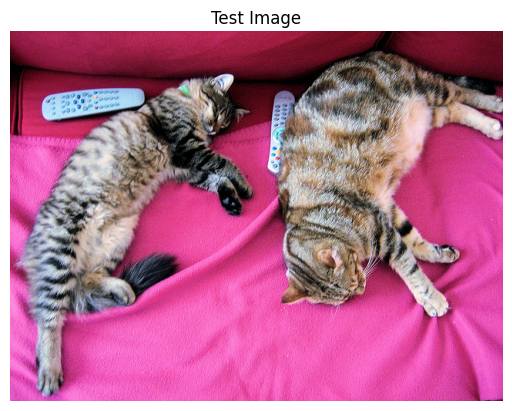

In [8]:
# Download a test image
url = "http://images.cocodataset.org/val2017/000000039769.jpg"
image = Image.open(requests.get(url, stream=True).raw)
plt.imshow(image)
plt.axis("off")
plt.title("Test Image")
plt.show()

inputs = processor(images=image, return_tensors="pt").to(device)

In [9]:
with torch.no_grad():
    base_out = base_model(**inputs)
    gated_out = gated_model(**inputs)

print(f"Output shape: {gated_out.last_hidden_state.shape}")

cos_sim = F.cosine_similarity(
    base_out.last_hidden_state.flatten(),
    gated_out.last_hidden_state.flatten(),
    dim=0,
)
print(f"Cosine similarity (base vs gated): {cos_sim.item():.4f}")
print("(High similarity expected since gate_proj is initialised near-identity)")

Output shape: torch.Size([1, 257, 768])
Cosine similarity (base vs gated): -0.0004
(High similarity expected since gate_proj is initialised near-identity)


# Finetuning only the gate on ImageNet-1k

In [10]:
from huggingface_hub import notebook_login
notebook_login()

In [11]:
from datasets import load_dataset

ds = load_dataset("clane9/imagenet-100")

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/17 [00:00<?, ?it/s]

In [12]:
train_ds, val_ds = ds['train'], ds['validation']

In [13]:
CLS_MODEL_NAME = "facebook/dinov2-small-imagenet1k-1-layer"

cls_processor = AutoImageProcessor.from_pretrained(CLS_MODEL_NAME)
cls_model = Dinov2ForImageClassification.from_pretrained(CLS_MODEL_NAME).to(device)
cls_model.classifier = nn.Linear(cls_model.config.hidden_size * 2, 100).to(device)

# Inject gated attention
inject_gated_attention(cls_model, cls_model.config)


cls_model = cls_model.to(device).eval()

Loading weights:   0%|          | 0/225 [00:00<?, ?it/s]

In [ ]:
import torch
from torch.utils.data import DataLoader
from torchvision import transforms
import tqdm

transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

def collate_fn(batch):
    images = torch.stack([transform(x["image"].convert("RGB")) for x in batch])
    labels = torch.tensor([x["label"] for x in batch])
    return images, labels

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, collate_fn=collate_fn, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, collate_fn=collate_fn, num_workers=0)

for name, param in cls_model.named_parameters():
    param.requires_grad = ("gate_proj" in name) or ("classifier" in name)

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, cls_model.parameters()),
    lr=1e-4,
    weight_decay=0.01,
)
criterion = torch.nn.CrossEntropyLoss()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cls_model.to(device)

for epoch in range(10):
    cls_model.train()
    total_loss, correct, total = 0, 0, 0

    for images, labels in tqdm.tqdm(train_loader):
        images, labels = images.to(device), labels.to(device)

        output = cls_model(images)
        logits = output.logits
        loss = criterion(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        total += images.size(0)

    train_acc = correct / total
    train_loss = total_loss / total

    cls_model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            logits = cls_model(images).logits
            val_correct += (logits.argmax(1) == labels).sum().item()
            val_total += images.size(0)

    val_acc = val_correct / val_total
    print(f"Epoch {epoch+1} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

100%|██████████| 3960/3960 [07:10<00:00,  9.19it/s]


Epoch 1 | Train Loss: 3.5109 | Train Acc: 0.1762 | Val Acc: 0.2342


100%|██████████| 3960/3960 [07:13<00:00,  9.13it/s]


Epoch 2 | Train Loss: 2.7774 | Train Acc: 0.3083 | Val Acc: 0.3158


100%|██████████| 3960/3960 [07:12<00:00,  9.15it/s]


...

Epoch 8 | Train Loss: 1.6022 | Train Acc: 0.5657 | Val Acc: 0.4336


100%|██████████| 3960/3960 [07:16<00:00,  9.07it/s]


Epoch 9 | Train Loss: 1.4814 | Train Acc: 0.5936 | Val Acc: 0.4302


100%|██████████| 3960/3960 [07:18<00:00,  9.03it/s]


Epoch 10 | Train Loss: 1.3646 | Train Acc: 0.6217 | Val Acc: 0.4320
